
# E11 — Detection Track  (Approach B: Two-Stage Detector)


# Architecture:
Stage 1  — YOLO      → bounding boxes + detection confidence  (localization)
 Stage 2  — Hybrid SVM → class label from SPPF + Classical     (recognition)
#
# YOLO's class prediction is NEVER used.
mAP is computed with:   confidence = YOLO detection confidence
class      = SVM class (from 508-dim hybrid features)
#

In [1]:
# ── CELL 0 ── Install dependencies (Colab only) ───────────────────────────────
!pip install ultralytics scikit-image -q


In [2]:
# ── CELL 1 ── Imports ─────────────────────────────────────────────────────────

import sys, os, time, json, warnings, datetime
from collections import defaultdict

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import joblib
import torch
import torchvision.transforms as T
from PIL import Image as PILImage
from ultralytics import YOLO
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops, hog

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, **kw: x

warnings.filterwarnings("ignore")

SEED      = 42
CLASSES   = ["BIODEGRADABLE", "CARDBOARD", "GLASS", "METAL", "PAPER", "PLASTIC"]
N_CLASSES = 6
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
np.random.seed(SEED)
torch.manual_seed(SEED)
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")


Device  : mps
PyTorch : 2.12.0


/Users/nadaashraf/Desktop/CV-Project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ── CELL 2 ── Drive mount + paths ─────────────────────────────────────────────

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IS_COLAB = True
    print("Running on Colab")
except ImportError:
    IS_COLAB = False
    print("Running locally")

# ── Adjust REPO_ROOT if your Drive layout is different ──
if IS_COLAB:
    REPO_ROOT = "/content/drive/MyDrive/CV/repo"
else:
    REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

sys.path.insert(0, REPO_ROOT)

MDL_DIR  = os.path.join(REPO_ROOT, "models")
RES_DIR  = os.path.join(REPO_ROOT, "results", "metrics")
FIG_DIR  = os.path.join(REPO_ROOT, "figures", "fusion")
PRED_DIR = os.path.join(REPO_ROOT, "results", "fusion")

for d in [RES_DIR, FIG_DIR, PRED_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"REPO_ROOT : {REPO_ROOT}")

Running locally
REPO_ROOT : /Users/nadaashraf/Desktop/CV-Project


In [6]:
import zipfile

zip_path    = os.path.join(REPO_ROOT, "data", "processed", "features", "dataset_split_70_15_15.zip")
extract_to  = os.path.join(REPO_ROOT, "data", "processed", "features")

if not os.path.isdir(os.path.join(extract_to, "dataset_split_70_15_15")):
    print("Extracting split dataset...")
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(extract_to)
    print("Done.")
else:
    print("Already extracted — skipping.")


Extracting split dataset...
Done.


In [8]:
# ── CELL 3 ── Locate test images ──────────────────────────────────────────────

# The zip extracts flat: test/ train/ val/ go directly into features/
# so SPLIT_DIR = the features folder itself
SPLIT_DIR    = os.path.join(REPO_ROOT, "data", "processed", "features")
TEST_IMG_DIR = os.path.join(SPLIT_DIR, "test", "images")
TEST_LBL_DIR = os.path.join(SPLIT_DIR, "test", "labels")

# Verify
assert os.path.isdir(TEST_IMG_DIR), f"Test images not found: {TEST_IMG_DIR}"
assert os.path.isdir(TEST_LBL_DIR), f"Test labels not found:  {TEST_LBL_DIR}"

TEST_IMAGES = sorted([
    f for f in os.listdir(TEST_IMG_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print(f"SPLIT_DIR    : {SPLIT_DIR}")
print(f"TEST_IMG_DIR : {TEST_IMG_DIR}")
print(f"TEST_LBL_DIR : {TEST_LBL_DIR}")
print(f"Test images  : {len(TEST_IMAGES)}")


SPLIT_DIR    : /Users/nadaashraf/Desktop/CV-Project/data/processed/features
TEST_IMG_DIR : /Users/nadaashraf/Desktop/CV-Project/data/processed/features/test/images
TEST_LBL_DIR : /Users/nadaashraf/Desktop/CV-Project/data/processed/features/test/labels
Test images  : 1570


In [9]:
# ── CELL 4 ── E1 baseline + detection constants ───────────────────────────────

# E1 per-class AP@0.5  (from results/metrics/detection_results.csv)
E1_AP = {
    "BIODEGRADABLE": 0.4663,
    "CARDBOARD":     0.4445,
    "GLASS":         0.4575,
    "METAL":         0.5161,
    "PAPER":         0.3939,
    "PLASTIC":       0.4572,
}
E1_MAP50 = 0.4559

# YOLO inference thresholds — keep identical to E1 for a fair comparison
CONF_THR = 0.25
NMS_IOU  = 0.45
MIN_CROP = 8      # skip predicted boxes smaller than 8×8 px

print(f"E1 baseline  mAP@0.5 = {E1_MAP50}")
print(f"YOLO thresholds  conf ≥ {CONF_THR}   NMS IoU ≤ {NMS_IOU}")


E1 baseline  mAP@0.5 = 0.4559
YOLO thresholds  conf ≥ 0.25   NMS IoU ≤ 0.45


In [11]:
# ── CELL 5 ── Load YOLO detector + E11 SVM + scalers ─────────────────────────
#
# YOLO is used for DETECTION ONLY.
# SVM is used for CLASSIFICATION ONLY.

YOLO_WEIGHTS = os.path.join(REPO_ROOT, "data", "processed", "features", "yolov8n_E1_best.pt")
SVM_PATH     = os.path.join(MDL_DIR, "e11_hybrid_svm_model.pkl")
SC_YOLO_PATH = os.path.join(MDL_DIR, "e11_scaler_yolo.pkl")
SC_CLS_PATH  = os.path.join(MDL_DIR, "e11_scaler_classical.pkl")

for path, name in [
    (YOLO_WEIGHTS, "YOLO weights"),
    (SVM_PATH,     "E11 SVM"),
    (SC_YOLO_PATH, "YOLO scaler"),
    (SC_CLS_PATH,  "Classical scaler"),
]:
    assert os.path.exists(path), f"{name} not found: {path}"

# --- YOLO detector ---
detector     = YOLO(YOLO_WEIGHTS)
nn_backbone  = detector.model          # DetectionModel (for SPPF hook)
nn_backbone.eval()
if DEVICE in ("cuda", "mps"):
    nn_backbone.to(DEVICE)

# --- E11 SVM classifier ---
svm     = joblib.load(SVM_PATH)
sc_yolo = joblib.load(SC_YOLO_PATH)
sc_cls  = joblib.load(SC_CLS_PATH)

print("✅ YOLO detector loaded   →  localization only")
print("✅ E11 Hybrid SVM loaded  →  classification only")
print("✅ Scalers loaded")


✅ YOLO detector loaded   →  localization only
✅ E11 Hybrid SVM loaded  →  classification only
✅ Scalers loaded


In [13]:
# ── CELL 6 ── SPPF feature extractor (256-dim) ────────────────────────────────
#
# Identical extraction pattern to Aly's E1 feature script:
#   - Forward hook on nn_backbone.model[9]  (SPPF layer in YOLOv8n)
#   - Preprocessing: divide by 255 only — no ImageNet normalisation (YOLO convention)
#   - Global Average Pool of hook output → [256]

_sppf_buf = {}
_sppf_handle = nn_backbone.model[9].register_forward_hook(
    lambda m, inp, out: _sppf_buf.update({"feat": out.detach()})
)

_to_tensor = T.Compose([T.ToTensor()])   # uint8 [0,255] → float32 [0,1], HWC→CHW

def extract_sppf(crop_rgb_224):
    """224×224 uint8 RGB array  →  256-dim float32 vector."""
    t = _to_tensor(PILImage.fromarray(crop_rgb_224)).unsqueeze(0)  # [1,3,224,224]
    t = t.to(DEVICE)

    with torch.no_grad():
        nn_backbone(t)                              # full forward → hook fires
    gap = _sppf_buf["feat"].mean(dim=[2, 3])        # GAP → [1, 256]
    return gap.cpu().numpy().flatten()              # [256]

# sanity check
_v = extract_sppf(np.zeros((224, 224, 3), dtype=np.uint8))
assert _v.shape == (256,), f"SPPF dim error: {_v.shape}"
print("✅ SPPF extractor ready — 256-dim")


✅ SPPF extractor ready — 256-dim


In [14]:
# ── CELL 7 ── Classical feature extractor (252-dim) ───────────────────────────
#
# Exact copy of src/features/classical_features.py
# Must stay identical to E2 / E11 classification track.

def _color_hist(img_rgb, bins=32):
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    return np.concatenate([
        np.histogram(hsv[:, :, ch], bins=bins, range=(0, 256), density=True)[0]
        for ch in range(3)
    ])  # 96

def _lbp(gray, n_points=24, radius=3):
    lbp = local_binary_pattern(gray, n_points, radius, method="uniform")
    h, _ = np.histogram(lbp.ravel(), bins=n_points + 2,
                        range=(0, n_points + 2), density=True)
    return h  # 26

def _gabor(gray):
    feats = []
    for freq in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]:
        for theta in [0, np.pi/4, np.pi/2, 3*np.pi/4]:
            k = cv2.getGaborKernel((21, 21), 5, theta, 1/freq, 0.5, 0, ktype=cv2.CV_32F)
            f = cv2.filter2D(gray.astype(np.float32), cv2.CV_32F, k)
            feats.extend([f.mean(), f.std()])
    return np.array(feats)  # 48

def _hog_feat(gray):
    f = hog(gray, orientations=9, pixels_per_cell=(8, 8),
            cells_per_block=(2, 2), feature_vector=True)
    return f[:36] if len(f) >= 36 else np.pad(f, (0, 36 - len(f)))  # 36

def _shape(gray):
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    cnts, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return np.zeros(10)
    c    = max(cnts, key=cv2.contourArea)
    area = cv2.contourArea(c)
    peri = cv2.arcLength(c, True)
    _, _, w, h = cv2.boundingRect(c)
    ar   = w / (h + 1e-6)
    circ = 4 * np.pi * area / (peri ** 2 + 1e-6)
    ext  = area / (w * h + 1e-6)
    hu   = cv2.HuMoments(cv2.moments(c)).flatten()
    return np.array([ar, circ, ext, *hu[:7]])  # 10

def _glcm(gray):
    g = graycomatrix(gray, distances=[1, 3],
                     angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                     levels=256, symmetric=True, normed=True)
    raw = np.concatenate([
        graycoprops(g, p).ravel()
        for p in ["contrast", "dissimilarity", "homogeneity", "energy", "correlation"]
    ])
    return raw[:36]  # 36

def extract_classical(crop_rgb_224):
    """224×224 uint8 RGB array  →  252-dim float64 vector."""
    gray = cv2.cvtColor(crop_rgb_224, cv2.COLOR_RGB2GRAY)
    vec  = np.concatenate([
        _color_hist(crop_rgb_224),   # 96
        _lbp(gray),                  # 26
        _gabor(gray),                # 48
        _hog_feat(gray),             # 36
        _shape(gray),                # 10
        _glcm(gray),                 # 36
    ])
    assert len(vec) == 252, f"Classical dim error: {len(vec)}"
    return vec

# sanity check
_v = extract_classical(np.zeros((224, 224, 3), dtype=np.uint8))
assert _v.shape == (252,)
print("✅ Classical extractor ready — 252-dim")



✅ Classical extractor ready — 252-dim


In [15]:
# ── CELL 8 ── mAP@0.5 utilities ───────────────────────────────────────────────

def parse_gt_label(lbl_path, img_w, img_h):
    """Read a YOLO-format .txt label → list of {class_id, box:[x1,y1,x2,y2]}."""
    boxes = []
    if not os.path.exists(lbl_path):
        return boxes
    with open(lbl_path) as fh:
        for line in fh:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls_id      = int(parts[0])
            xc, yc, bw, bh = map(float, parts[1:])
            x1 = int((xc - bw / 2) * img_w)
            y1 = int((yc - bh / 2) * img_h)
            x2 = int((xc + bw / 2) * img_w)
            y2 = int((yc + bh / 2) * img_h)
            boxes.append({"class_id": cls_id, "box": [x1, y1, x2, y2]})
    return boxes


def box_iou(b1, b2):
    """IoU between two [x1,y1,x2,y2] boxes."""
    ix1, iy1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    ix2, iy2 = min(b1[2], b2[2]), min(b1[3], b2[3])
    if ix2 <= ix1 or iy2 <= iy1:
        return 0.0
    inter = (ix2 - ix1) * (iy2 - iy1)
    a1    = (b1[2] - b1[0]) * (b1[3] - b1[1])
    a2    = (b2[2] - b2[0]) * (b2[3] - b2[1])
    return inter / (a1 + a2 - inter + 1e-9)


def _voc_ap(tp_arr, fp_arr, n_gt):
    """Area-under-PR-curve AP from confidence-sorted TP/FP arrays."""
    tp_c  = np.cumsum(tp_arr)
    fp_c  = np.cumsum(fp_arr)
    rec   = tp_c / (n_gt + 1e-9)
    prec  = tp_c / (tp_c + fp_c + 1e-9)
    r     = np.concatenate([[0.0], rec,  [rec[-1]]])
    p     = np.concatenate([[1.0], prec, [0.0]])
    for i in range(len(p) - 2, -1, -1):
        p[i] = max(p[i], p[i + 1])
    chg = np.where(r[1:] != r[:-1])[0] + 1
    return float(np.sum((r[chg] - r[chg - 1]) * p[chg]))


def compute_map50(all_preds_by_cls, all_gt_by_cls):
    """
    all_preds_by_cls : {cls_id: [(img_id, [x1,y1,x2,y2], yolo_conf), ...]}
    all_gt_by_cls    : {cls_id: {img_id: [[x1,y1,x2,y2], ...]}}
    Returns: per-class AP dict, mAP float
    """
    aps = {}
    for cls_id in range(N_CLASSES):
        preds = all_preds_by_cls.get(cls_id, [])
        gt    = all_gt_by_cls.get(cls_id, {})
        n_gt  = sum(len(v) for v in gt.values())

        if n_gt == 0 or len(preds) == 0:
            aps[cls_id] = 0.0
            continue

        # Sort by YOLO detection confidence descending
        preds_s = sorted(preds, key=lambda x: x[2], reverse=True)
        matched = defaultdict(set)
        tp = np.zeros(len(preds_s))
        fp = np.zeros(len(preds_s))

        for i, (img_id, pred_box, _conf) in enumerate(preds_s):
            gt_boxes          = gt.get(img_id, [])
            best_iou, best_j  = 0.0, -1
            for j, gb in enumerate(gt_boxes):
                if j in matched[img_id]:
                    continue
                ov = box_iou(pred_box, gb)
                if ov > best_iou:
                    best_iou, best_j = ov, j
            if best_iou >= 0.5 and best_j >= 0:
                tp[i] = 1.0
                matched[img_id].add(best_j)
            else:
                fp[i] = 1.0

        aps[cls_id] = _voc_ap(tp, fp, n_gt)

    return aps, float(np.mean(list(aps.values())))


print("✅ mAP utilities ready")

✅ mAP utilities ready


In [16]:

# ── CELL 9 ── MAIN LOOP — Two-stage detection pipeline ────────────────────────
#
#   Stage 1: YOLO  →  bounding boxes + detection confidence   (localization)
#   Stage 2: SVM   →  class label from SPPF + Classical       (recognition)
#
# YOLO class predictions are loaded but NEVER used as the final class.
# They are only stored for the analysis log (how often does SVM agree/disagree).

# Prediction accumulators
all_preds_by_cls = defaultdict(list)              # cls_id → [(img_id, box, yolo_conf)]
all_gt_by_cls    = defaultdict(lambda: defaultdict(list))  # cls_id → {img_id → [boxes]}

# Analysis log (optional, useful for the report)
analysis_log  = []   # one row per detected box
n_total       = 0
n_svm_ne_yolo = 0    # how many times SVM class ≠ YOLO class

print(f"Starting E11 two-stage detection on {len(TEST_IMAGES)} test images...")
print(f"  YOLO: localization  (conf ≥ {CONF_THR}, NMS IoU ≤ {NMS_IOU})")
print(f"  SVM : classification (508-dim SPPF + Classical)\n")
t0 = time.time()

for img_fname in tqdm(TEST_IMAGES, desc="E11 detection"):
    img_id   = os.path.splitext(img_fname)[0]
    img_path = os.path.join(TEST_IMG_DIR, img_fname)
    lbl_path = os.path.join(TEST_LBL_DIR, img_id + ".txt")

    # ── Load image ──
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        continue
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H, W     = img_rgb.shape[:2]

    # ── Collect ground-truth boxes ──
    for gt in parse_gt_label(lbl_path, W, H):
        all_gt_by_cls[gt["class_id"]][img_id].append(gt["box"])

    # ── Stage 1: YOLO detection ──
    results = detector.predict(
        img_path,
        conf=CONF_THR, iou=NMS_IOU,
        verbose=False, device=DEVICE,
    )
    if not results or results[0].boxes is None or len(results[0].boxes) == 0:
        continue

    det          = results[0].boxes
    boxes_xyxy   = det.xyxy.cpu().numpy()             # [N, 4]  absolute pixels
    yolo_confs   = det.conf.cpu().numpy()             # [N]     detection confidence
    yolo_classes = det.cls.cpu().numpy().astype(int)  # [N]     YOLO class (not used as final)

    # ── Stage 2: per-box hybrid classification ──
    for box, yolo_conf, yolo_cls in zip(boxes_xyxy, yolo_confs, yolo_classes):

        # Clamp box to image bounds
        x1 = max(0, int(box[0]));  y1 = max(0, int(box[1]))
        x2 = min(W, int(box[2]));  y2 = min(H, int(box[3]))

        if (x2 - x1) < MIN_CROP or (y2 - y1) < MIN_CROP:
            continue

        # Crop the detected region → 224×224
        crop_224 = cv2.resize(
            img_rgb[y1:y2, x1:x2], (224, 224), interpolation=cv2.INTER_LINEAR
        )

        # Extract SPPF features (256-dim) + Classical features (252-dim)
        feat_sppf = extract_sppf(crop_224)        # [256]
        feat_cls  = extract_classical(crop_224)   # [252]

        # Scale each branch independently, then fuse → 508-dim
        fs = sc_yolo.transform(feat_sppf.reshape(1, -1))  # [1, 256]
        fc = sc_cls.transform(feat_cls.reshape(1, -1))    # [1, 252]
        fused = np.hstack([fs, fc])                        # [1, 508]

        # SVM classification — this is the ONLY source of the class label
        svm_proba = svm.predict_proba(fused)[0]   # [6]
        svm_cls   = int(np.argmax(svm_proba))
        svm_conf  = float(svm_proba[svm_cls])

        # Store prediction:
        #   class  = SVM  (recognition)
        #   conf   = YOLO (localization quality — used for mAP sorting)
        all_preds_by_cls[svm_cls].append(
            (img_id, [x1, y1, x2, y2], float(yolo_conf))
        )

        # Log for analysis
        analysis_log.append({
            "img_id"    : img_id,
            "svm_cls"   : svm_cls,
            "svm_name"  : CLASSES[svm_cls],
            "svm_conf"  : round(svm_conf, 4),
            "yolo_cls"  : yolo_cls,
            "yolo_name" : CLASSES[yolo_cls],
            "yolo_conf" : round(float(yolo_conf), 4),
            "agree"     : svm_cls == yolo_cls,
        })

        n_total += 1
        if svm_cls != yolo_cls:
            n_svm_ne_yolo += 1

elapsed = time.time() - t0
print(f"\nDone in {elapsed:.1f}s  ({1000*elapsed/len(TEST_IMAGES):.1f} ms/image)")
print(f"  Total boxes classified : {n_total}")
print(f"  SVM agreed with YOLO   : {n_total - n_svm_ne_yolo}  "
      f"({100*(n_total-n_svm_ne_yolo)/max(1,n_total):.1f}%)")
print(f"  SVM differed from YOLO : {n_svm_ne_yolo}  "
      f"({100*n_svm_ne_yolo/max(1,n_total):.1f}%)")


Starting E11 two-stage detection on 1570 test images...
  YOLO: localization  (conf ≥ 0.25, NMS IoU ≤ 0.45)
  SVM : classification (508-dim SPPF + Classical)



E11 detection: 100%|██████████| 1570/1570 [08:09<00:00,  3.21it/s] 


Done in 489.1s  (311.5 ms/image)
  Total boxes classified : 8340
  SVM agreed with YOLO   : 7107  (85.2%)
  SVM differed from YOLO : 1233  (14.8%)


In [17]:
# ── CELL 10 ── Compute mAP@0.5 ────────────────────────────────────────────────

aps, mAP50 = compute_map50(all_preds_by_cls, all_gt_by_cls)

print("=" * 60)
print("  E11 TWO-STAGE DETECTION RESULTS")
print("=" * 60)
print(f"\n  {'':30s} {'mAP@0.5':>8}")
print(f"  {'E1  (YOLO — single stage)':30s} {E1_MAP50:>8.4f}")
print(f"  {'E11 (YOLO + Hybrid SVM)':30s} {mAP50:>8.4f}   "
      f"Δ = {mAP50 - E1_MAP50:+.4f}")
print()
print(f"  {'Class':<18} {'E1 AP':>8} {'E11 AP':>8} {'Δ':>9}")
print("  " + "─" * 45)
for i, cls in enumerate(CLASSES):
    e1  = E1_AP[cls]
    e11 = aps.get(i, 0.0)
    d   = e11 - e1
    arrow = " ↑" if d > 0.001 else (" ↓" if d < -0.001 else "  ")
    print(f"  {cls:<18} {e1:>8.4f} {e11:>8.4f} {d:>+9.4f}{arrow}")
print("=" * 60)


  E11 TWO-STAGE DETECTION RESULTS

                                  mAP@0.5
  E1  (YOLO — single stage)        0.4559
  E11 (YOLO + Hybrid SVM)          0.3840   Δ = -0.0719

  Class                 E1 AP   E11 AP         Δ
  ─────────────────────────────────────────────
  BIODEGRADABLE        0.4663   0.4441   -0.0222 ↓
  CARDBOARD            0.4445   0.3915   -0.0530 ↓
  GLASS                0.4575   0.3826   -0.0749 ↓
  METAL                0.5161   0.4065   -0.1096 ↓
  PAPER                0.3939   0.3256   -0.0683 ↓
  PLASTIC              0.4572   0.3537   -0.1035 ↓


In [18]:

# ── CELL 11 ── Analysis — where do SVM and YOLO disagree? ─────────────────────

if analysis_log:
    df_log = pd.DataFrame(analysis_log)
    df_diff = df_log[~df_log["agree"]]

    print(f"SVM classification vs YOLO classification:\n")
    print(f"  Agreement rate   : {100*df_log['agree'].mean():.1f}%  "
          f"({df_log['agree'].sum()} / {len(df_log)} boxes)")
    print(f"  Disagreement rate: {100*(~df_log['agree']).mean():.1f}%  "
          f"({len(df_diff)} boxes)\n")

    if len(df_diff):
        print("Top disagreement pairs (YOLO class → SVM class):")
        pairs = (
            df_diff.groupby(["yolo_name", "svm_name"])
            .size()
            .sort_values(ascending=False)
        )
        for (y, s), cnt in pairs.head(10).items():
            print(f"  {y:>18}  →  {s:<18}  {cnt:4d} boxes")

        print(f"\nAvg YOLO confidence on disagreed boxes : "
              f"{df_diff['yolo_conf'].mean():.3f}")
        print(f"Avg SVM  confidence on disagreed boxes : "
              f"{df_diff['svm_conf'].mean():.3f}")



SVM classification vs YOLO classification:

  Agreement rate   : 85.2%  (7107 / 8340 boxes)
  Disagreement rate: 14.8%  (1233 boxes)

Top disagreement pairs (YOLO class → SVM class):
               METAL  →  GLASS                 92 boxes
               GLASS  →  METAL                 91 boxes
               GLASS  →  BIODEGRADABLE         80 boxes
               METAL  →  BIODEGRADABLE         75 boxes
               METAL  →  PAPER                 72 boxes
             PLASTIC  →  BIODEGRADABLE         66 boxes
             PLASTIC  →  METAL                 65 boxes
               METAL  →  PLASTIC               57 boxes
             PLASTIC  →  PAPER                 56 boxes
       BIODEGRADABLE  →  PLASTIC               54 boxes

Avg YOLO confidence on disagreed boxes : 0.508
Avg SVM  confidence on disagreed boxes : 0.668


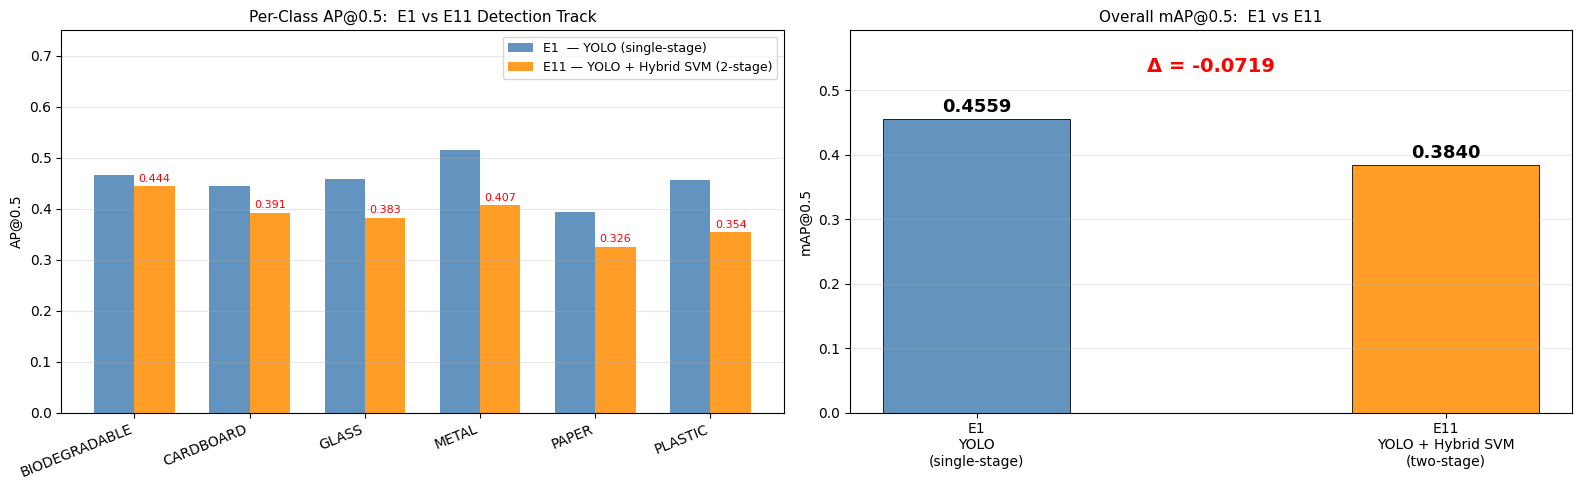

Figure saved: /Users/nadaashraf/Desktop/CV-Project/figures/fusion/E11_vs_E1_detection.png


In [19]:
# ── CELL 12 ── Plots ───────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ─ Left: per-class AP comparison ─
x      = np.arange(N_CLASSES)
w      = 0.35
e1_aps  = [E1_AP[c] for c in CLASSES]
e11_aps = [aps.get(i, 0.0) for i in range(N_CLASSES)]
deltas  = [e11 - e1 for e1, e11 in zip(e1_aps, e11_aps)]

ax = axes[0]
b1 = ax.bar(x - w/2, e1_aps,  w, label="E1  — YOLO (single-stage)",      color="steelblue",  alpha=0.85)
b2 = ax.bar(x + w/2, e11_aps, w, label="E11 — YOLO + Hybrid SVM (2-stage)", color="darkorange", alpha=0.85)
for b, v, d in zip(b2, e11_aps, deltas):
    clr = "green" if d > 0 else "red"
    ax.text(b.get_x() + b.get_width()/2, v + 0.005,
            f"{v:.3f}", ha="center", va="bottom", fontsize=8, color=clr)
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=22, ha="right", fontsize=10)
ax.set_ylabel("AP@0.5")
ax.set_ylim(0, 0.75)
ax.set_title("Per-Class AP@0.5:  E1 vs E11 Detection Track", fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# ─ Right: mAP summary ─
ax2    = axes[1]
labels = ["E1\nYOLO\n(single-stage)", "E11\nYOLO + Hybrid SVM\n(two-stage)"]
vals   = [E1_MAP50, mAP50]
cols   = ["steelblue", "darkorange"]
bars   = ax2.bar(labels, vals, width=0.4, color=cols, alpha=0.85,
                 edgecolor="black", linewidth=0.7)
ax2.set_ylim(0, max(vals) * 1.3)
ax2.set_ylabel("mAP@0.5")
ax2.set_title("Overall mAP@0.5:  E1 vs E11", fontsize=11)
ax2.grid(axis="y", alpha=0.3)
for b, v in zip(bars, vals):
    ax2.text(b.get_x() + b.get_width()/2, v + 0.004,
             f"{v:.4f}", ha="center", va="bottom", fontsize=13, fontweight="bold")
d_col = "green" if mAP50 >= E1_MAP50 else "red"
ax2.text(0.5, 0.93, f"Δ = {mAP50 - E1_MAP50:+.4f}",
         ha="center", va="top", transform=ax2.transAxes,
         fontsize=14, fontweight="bold", color=d_col)

plt.tight_layout()
fig_path = os.path.join(FIG_DIR, "E11_vs_E1_detection.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig_path}")

In [20]:

# ── CELL 13 ── Save results ────────────────────────────────────────────────────

# detection_results.csv
det_csv = os.path.join(RES_DIR, "detection_results.csv")
e11_row = {
    "experiment"         : "E11",
    "model"              : "TwoStage_YOLO+HybridSVM",
    "timestamp"          : datetime.datetime.now().strftime("%Y-%m-%d %H:%M"),
    "map50"              : round(mAP50, 4),
    "map50_95"           : None,
    "precision"          : None,
    "recall"             : None,
    "fps"                : None,
    "model_size_mb"      : None,
    "feature_dim"        : 508,
    "map50_BIODEGRADABLE": round(aps.get(0, 0.0), 4),
    "map50_CARDBOARD"    : round(aps.get(1, 0.0), 4),
    "map50_GLASS"        : round(aps.get(2, 0.0), 4),
    "map50_METAL"        : round(aps.get(3, 0.0), 4),
    "map50_PAPER"        : round(aps.get(4, 0.0), 4),
    "map50_PLASTIC"      : round(aps.get(5, 0.0), 4),
    "n_boxes"            : n_total,
    "svm_yolo_agree_rate": round((n_total - n_svm_ne_yolo) / max(1, n_total), 4),
}

df_det = pd.read_csv(det_csv) if os.path.exists(det_csv) else pd.DataFrame()
df_det = df_det[df_det.get("experiment", pd.Series(dtype=str)) != "E11"] \
         if len(df_det) else df_det
df_det = pd.concat([df_det, pd.DataFrame([e11_row])], ignore_index=True)
df_det.to_csv(det_csv, index=False)
print(f"Saved: {det_csv}")

# Analysis log CSV
if analysis_log:
    log_path = os.path.join(PRED_DIR, "e11_detection_analysis_log.csv")
    pd.DataFrame(analysis_log).to_csv(log_path, index=False)
    print(f"Saved analysis log ({len(analysis_log)} rows): {log_path}")

print()
print("=" * 60)
print("  E11 DETECTION TRACK COMPLETE")
print(f"  mAP@0.5  E1  = {E1_MAP50:.4f}")
print(f"  mAP@0.5  E11 = {mAP50:.4f}    Δ = {mAP50 - E1_MAP50:+.4f}")
verdict = "IMPROVEMENT ↑" if mAP50 > E1_MAP50 else "NO IMPROVEMENT ↓"
print(f"  {verdict}")
print("=" * 60)


Saved: /Users/nadaashraf/Desktop/CV-Project/results/metrics/detection_results.csv
Saved analysis log (8340 rows): /Users/nadaashraf/Desktop/CV-Project/results/fusion/e11_detection_analysis_log.csv

  E11 DETECTION TRACK COMPLETE
  mAP@0.5  E1  = 0.4559
  mAP@0.5  E11 = 0.3840    Δ = -0.0719
  NO IMPROVEMENT ↓
